### Explainable Deepfake Audio Detection with Confidence Calibration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/LA_Subset.zip"

In [ ]:
import subprocess
subprocess.run(['7z', 'x', zip_path, '-o/content/LA_Subset', '-y'])

CompletedProcess(args=['7z', 'x', '/content/drive/MyDrive/LA_Subset.zip', '-o/content/LA_Subset', '-y'], returncode=0)

In [ ]:
import os
print(os.listdir('/content/LA_Subset/LA_Subset'))

['ASVspoof2019_LA_dev', 'ASVspoof2019_LA_train', 'ASVspoof2019_LA_cm_protocols']


In [ ]:
base = '/content/LA_Subset/LA_Subset'
for folder in os.listdir(base):
    print(f'\n{folder}:')
    print(os.listdir(f'{base}/{folder}'))


ASVspoof2019_LA_dev:
['LICENSE.txt', 'flac']

ASVspoof2019_LA_train:
['LICENSE.txt', 'flac']

ASVspoof2019_LA_cm_protocols:
['ASVspoof2019.LA.cm.train.trn.txt', 'ASVspoof2019.LA.cm.dev.trl.txt']


#### Install all required dependencies

In [ ]:
import os
import shutil

In [ ]:
!pip install librosa shap scikit-learn pandas numpy matplotlib seaborn reportlab soundfile joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.4 MB/s eta 0:00:00


In [ ]:
!pip install shap reportlab --quiet
print("Setup complete.")

Setup complete.


##### Configuration Constants

In [ ]:
# Central Paths Config (pointing to extracted local Colab files)
DATASET_BASE = "/content/LA_Subset/LA_Subset"
OUTPUT_DIR = "/content/project_outputs"

MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
FEATURE_DIR = os.path.join(OUTPUT_DIR, "features")

In [ ]:
# Create directories
for path in [OUTPUT_DIR, MODEL_DIR, PLOT_DIR, REPORT_DIR, FEATURE_DIR]:
    os.makedirs(path, exist_ok=True)

# DSP Configuration
SAMPLE_RATE = 16000           # 16 kHz forced resampling
PRE_EMPHASIS = 0.97           # High-pass filter coefficient
SILENCE_TOP_DB = 20           # Silent frames threshold

In [ ]:
# MFCC Configuration
N_MFCC = 40
WINDOW_MS = 25
HOP_MS = 10
N_FFT = int(SAMPLE_RATE * (WINDOW_MS / 1000.0))  # 400 samples
HOP_LENGTH = int(SAMPLE_RATE * (HOP_MS / 1000.0)) # 160 samples
WIN_LENGTH = N_FFT
WINDOW_TYPE = 'hamming'

In [ ]:
# Sampling sizes for balanced training (avoids class-imbalance bias)
TRAIN_BONAFIDE_SIZE = 1500
TRAIN_SPOOF_SIZE = 1500
VAL_BONAFIDE_SIZE = 500
VAL_SPOOF_SIZE = 500

In [ ]:
RANDOM_STATE = 42
print("Configuration loaded successfully.")

Configuration loaded successfully.


#### Metadata Parser and Stratified Sampler

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def parse_protocol_file(file_path):
    # Reads the space-separated text files
    df = pd.read_csv(file_path, sep=r'\s+', header=None,
                     names=['speaker_id', 'file_id', 'dummy', 'attack_id', 'label'])
    df['label_num'] = df['label'].map({'bonafide': 0, 'spoof': 1})
    return df

In [ ]:
def get_audio_path(file_id, subset):
    if subset == 'train':
        folder_name = "ASVspoof2019_LA_train"
    elif subset in ['dev', 'val']:
        folder_name = "ASVspoof2019_LA_dev"
    else:
        raise ValueError(f"Unknown subset: {subset}")
    return os.path.join(DATASET_BASE, folder_name, "flac", f"{file_id}.flac")


In [ ]:

# Run Verification
train_proto_path = os.path.join(DATASET_BASE, "ASVspoof2019_LA_cm_protocols", "ASVspoof2019.LA.cm.train.trn.txt")
dev_proto_path = os.path.join(DATASET_BASE, "ASVspoof2019_LA_cm_protocols", "ASVspoof2019.LA.cm.dev.trl.txt")
# Load dataframes
train_df = parse_protocol_file(train_proto_path)
dev_df = parse_protocol_file(dev_proto_path)

In [ ]:
# --- Perform EDA (Exploratory Data Analysis) ---
print(f"Total training samples: {len(train_df)}")
print(f"Total validation samples: {len(dev_df)}")

Total training samples: 25380
Total validation samples: 24844


In [ ]:
train_counts = train_df['label'].value_counts()
dev_counts = dev_df['label'].value_counts()
print("\n--- Train Class Distribution (Highly Imbalanced) ---")
for lbl, cnt in train_counts.items():
    print(f"  {lbl}: {cnt} ({cnt/len(train_df)*100:.2f}%)")


--- Train Class Distribution (Highly Imbalanced) ---
  spoof: 22800 (89.83%)
  bonafide: 2580 (10.17%)


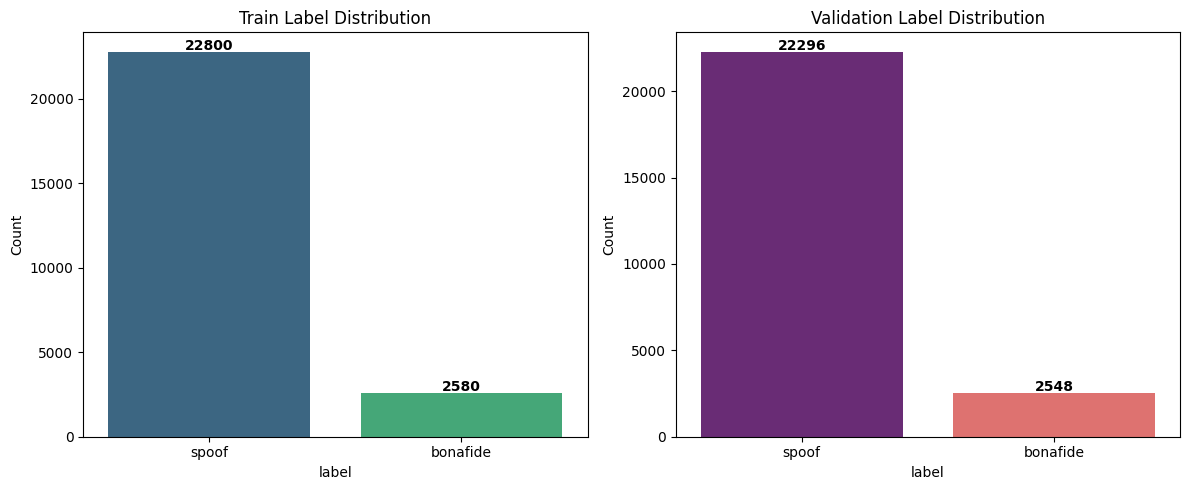

In [ ]:
# Save distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], hue=train_counts.index, palette='viridis', legend=False)
axes[0].set_title("Train Label Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 100, f"{v}", ha='center', fontweight='bold')

sns.barplot(x=dev_counts.index, y=dev_counts.values, ax=axes[1], hue=dev_counts.index, palette='magma', legend=False)
axes[1].set_title("Validation Label Distribution")
axes[1].set_ylabel("Count")
for i, v in enumerate(dev_counts.values):
    axes[1].text(i, v + 100, f"{v}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "class_distribution.png"), dpi=200)
plt.show()

In [ ]:

# --- Create Stratified Balanced Subsets ---
np.random.seed(RANDOM_STATE)
train_bonafide = train_df[train_df['label'] == 'bonafide'].sample(TRAIN_BONAFIDE_SIZE, random_state=RANDOM_STATE)
train_spoof = train_df[train_df['label'] == 'spoof'].sample(TRAIN_SPOOF_SIZE, random_state=RANDOM_STATE)
train_subset = pd.concat([train_bonafide, train_spoof]).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

In [ ]:
dev_bonafide = dev_df[dev_df['label'] == 'bonafide'].sample(VAL_BONAFIDE_SIZE, random_state=RANDOM_STATE)
dev_spoof = dev_df[dev_df['label'] == 'spoof'].sample(VAL_SPOOF_SIZE, random_state=RANDOM_STATE)
val_subset = pd.concat([dev_bonafide, dev_spoof]).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

In [ ]:
# Save subset metadata files to disk
train_subset.to_csv(os.path.join(OUTPUT_DIR, "train_subset_metadata.csv"), index=False)
val_subset.to_csv(os.path.join(OUTPUT_DIR, "val_subset_metadata.csv"), index=False)
print("Balanced subsets created and metadata saved.")

Balanced subsets created and metadata saved.


####  EDA - Audio Signal Preprocessing & Spectrogram Visualization

In [ ]:
import librosa
import librosa.display

In [ ]:
def pre_emphasis_filter(y, alpha=PRE_EMPHASIS):
    if len(y) == 0:
        return y
    return np.append(y[0], y[1:] - alpha * y[:-1])

In [ ]:
def preprocess_audio(file_path):
    # 1. Resample to 16 kHz
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    # 2. Pre-emphasis filtering to boost high frequencies
    y_pre = pre_emphasis_filter(y)
    # 3. Silence Trimming
    y_trimmed, _ = librosa.effects.trim(y_pre, top_db=SILENCE_TOP_DB)
    if len(y_trimmed) == 0:
        y_trimmed = y_pre
    # 4. Amplitude Normalisation
    max_val = np.max(np.abs(y_trimmed))
    if max_val > 0:
        y_norm = y_trimmed / max_val
    else:
        y_norm = y_trimmed
    return y_norm

In [ ]:
def plot_waveform_and_spectrogram(file_path, label, save_name):
    y_raw, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    y_proc = preprocess_audio(file_path)

    fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    # 1. Raw Waveform
    librosa.display.waveshow(y_raw, sr=SAMPLE_RATE, ax=axes[0], color='blue', alpha=0.6)
    axes[0].set_title(f"Raw Waveform - {label} ({os.path.basename(file_path)})")
    axes[0].set_ylabel("Amplitude")

    # 2. Preprocessed Waveform
    librosa.display.waveshow(y_proc, sr=SAMPLE_RATE, ax=axes[1], color='green', alpha=0.6)
    axes[1].set_title("Preprocessed Waveform (Pre-emphasis, Trimmed, Normalised)")
    axes[1].set_ylabel("Amplitude")

    # 3. Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y_proc, sr=SAMPLE_RATE, n_fft=N_FFT,
                                      hop_length=HOP_LENGTH, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='mel', ax=axes[2], cmap='viridis')
    axes[2].set_title("Mel Spectrogram (Preprocessed)")
    fig.colorbar(img, ax=axes[2], format='%+2.0f dB')

    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{save_name}.png"), dpi=200)
    plt.show()


--- Visualizing Genuine Audio Signal ---


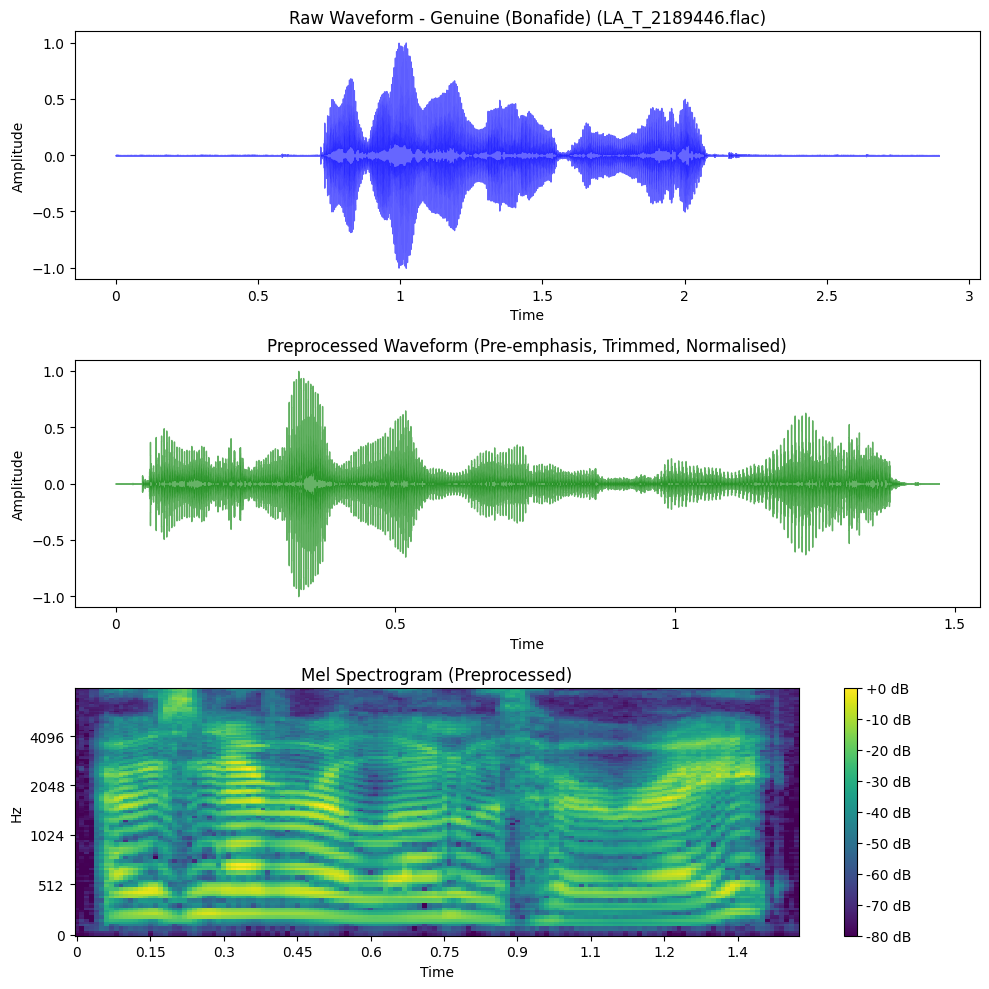


--- Visualizing Deepfake Audio Signal ---


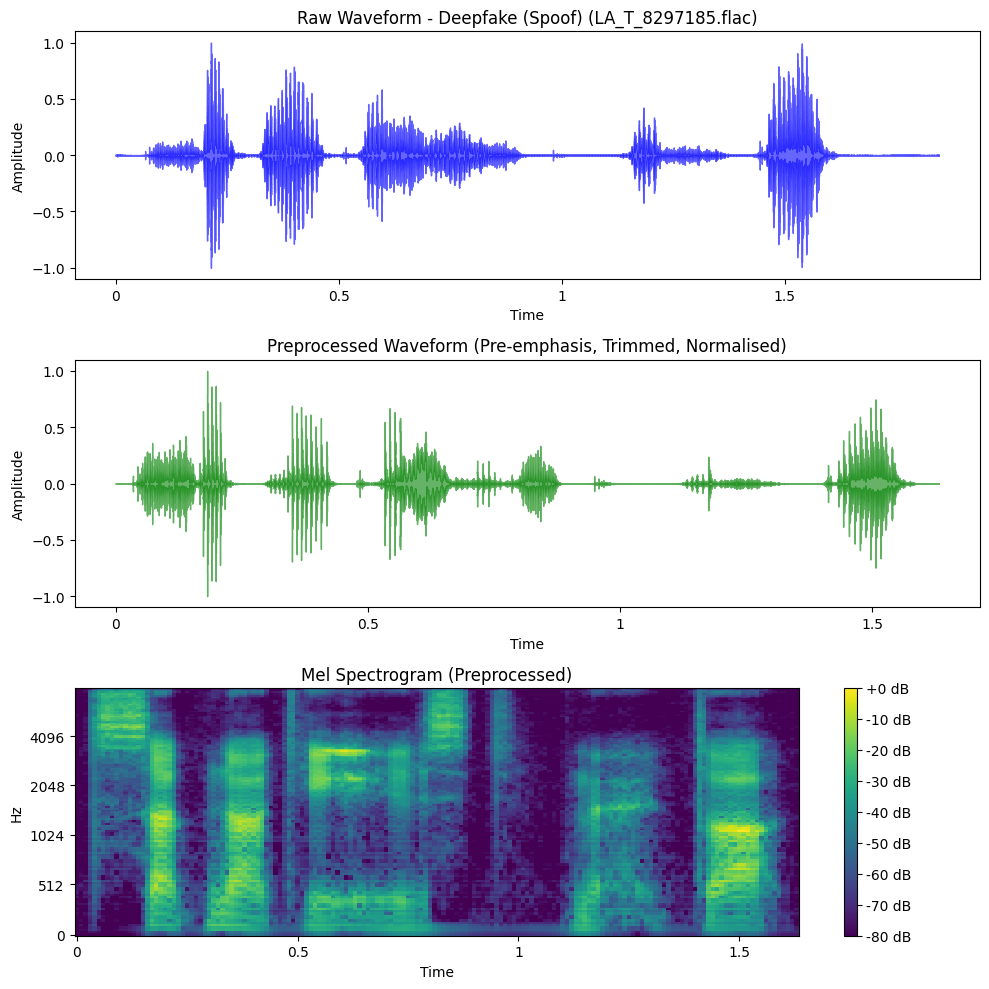

In [ ]:
# Visualize one bonafide sample and one spoof sample
bonafide_sample = train_subset[train_subset['label'] == 'bonafide'].iloc[0]
spoof_sample = train_subset[train_subset['label'] == 'spoof'].iloc[0]
b_path = get_audio_path(bonafide_sample['file_id'], 'train')
s_path = get_audio_path(spoof_sample['file_id'], 'train')
print("\n--- Visualizing Genuine Audio Signal ---")
plot_waveform_and_spectrogram(b_path, "Genuine (Bonafide)", "sample_bonafide_signal")
print("\n--- Visualizing Deepfake Audio Signal ---")
plot_waveform_and_spectrogram(s_path, "Deepfake (Spoof)", "sample_spoof_signal")

#### MFCC Feature Extraction Loop & Scaler Saving

In [ ]:
import time
import joblib
from sklearn.preprocessing import StandardScaler

In [ ]:
def extract_mfcc_features(y):
    # Extract 40 MFCCs with a Hamming window
    mfccs = librosa.feature.mfcc(
        y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC, n_fft=N_FFT,
        hop_length=HOP_LENGTH, win_length=WIN_LENGTH, window=WINDOW_TYPE
    )
    # Average and Standard deviation across time frames
    mean_agg = np.mean(mfccs, axis=1)
    std_agg = np.std(mfccs, axis=1)
    # Concatenate to 80-dimensional feature vector
    return np.concatenate([mean_agg, std_agg])

In [ ]:
def extract_subset_features(subset_df, subset_name):
    X, y = [], []
    start = time.time()
    for idx, row in subset_df.iterrows():
        file_path = get_audio_path(row['file_id'], subset_name)
        try:
            y_audio = preprocess_audio(file_path)
            feats = extract_mfcc_features(y_audio)
            X.append(feats)
            y.append(row['label_num'])
        except Exception as e:
            print(f"Skipping {row['file_id']}: {e}")
        if (idx + 1) % 500 == 0:
            print(f"  Processed {idx + 1}/{len(subset_df)} files...")
    print(f"Extraction for '{subset_name}' finished in {time.time()-start:.2f}s")
    return np.array(X), np.array(y)

In [ ]:
print("Extracting features for train subset...")
X_train_raw, y_train = extract_subset_features(train_subset, 'train')
print("Extracting features for validation subset...")
X_val_raw, y_val = extract_subset_features(val_subset, 'dev')

Extracting features for train subset...
  Processed 500/3000 files...
  Processed 1000/3000 files...
  Processed 1500/3000 files...
  Processed 2000/3000 files...
  Processed 2500/3000 files...
  Processed 3000/3000 files...
Extraction for 'train' finished in 47.51s
Extracting features for validation subset...
  Processed 500/1000 files...
  Processed 1000/1000 files...
Extraction for 'dev' finished in 19.26s


In [ ]:
# Fit Scaler and Standardise Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)


In [ ]:
# Save arrays
np.save(os.path.join(FEATURE_DIR, "X_train_scaled.npy"), X_train)
np.save(os.path.join(FEATURE_DIR, "y_train.npy"), y_train)
np.save(os.path.join(FEATURE_DIR, "X_val_scaled.npy"), X_val)
np.save(os.path.join(FEATURE_DIR, "y_val.npy"), y_val)

In [ ]:
# SAVE FITTED SCALER TO DISK (Crucial for future inference!)
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
print("Features and scaler saved to disk successfully.")

Features and scaler saved to disk successfully.


In [ ]:
# print("DSP & Feature Extraction functions defined.")

DSP & Feature Extraction functions defined.


#### Model Training, Tuning & Evaluation

In [ ]:
# Fits the Random Forest model and tunes it using GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve
)
import joblib

In [ ]:
# 1. Train and save baseline Random Forest
print("Training Baseline Random Forest...")
rf_base = RandomForestClassifier(n_estimators=300, class_weight='balanced', oob_score=True, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train, y_train)
joblib.dump(rf_base, os.path.join(MODEL_DIR, "rf_model.pkl"))

Training Baseline Random Forest...


['/content/project_outputs/models/rf_model.pkl']

In [ ]:
# 2. Hyperparameter Grid Search Tuning
print("Tuning Random Forest via Grid Search...")
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rf_grid = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
grid = GridSearchCV(rf_grid, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
print(f"Best parameters found: {grid.best_params_}")

Tuning Random Forest via Grid Search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}


In [ ]:
# SAVE TUNED MODEL TO DISK (Prevents loss of progress!)
joblib.dump(best_rf, os.path.join(MODEL_DIR, "best_rf_model.pkl"))

['/content/project_outputs/models/best_rf_model.pkl']

In [ ]:
# 3. Evaluate both models and compile metrics
def get_metrics_dict(model, model_name):
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    return {
        "Model": model_name,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob)
    }
baseline_metrics = get_metrics_dict(rf_base, "Baseline Random Forest")
best_metrics = get_metrics_dict(best_rf, "Tuned Random Forest")


In [ ]:
# Print report
for m in [baseline_metrics, best_metrics]:
    print(f"\n--- {m['Model']} Evaluation Report ---")
    print(f"Confusion Matrix: TP={m['TP']}, TN={m['TN']}, FP={m['FP']}, FN={m['FN']}")
    print(f"Accuracy:  {m['Accuracy']:.4f} | Precision: {m['Precision']:.4f} | Recall: {m['Recall']:.4f} | F1: {m['F1-Score']:.4f}")


--- Baseline Random Forest Evaluation Report ---
Confusion Matrix: TP=412, TN=406, FP=94, FN=88
Accuracy:  0.8180 | Precision: 0.8142 | Recall: 0.8240 | F1: 0.8191

--- Tuned Random Forest Evaluation Report ---
Confusion Matrix: TP=403, TN=412, FP=88, FN=97
Accuracy:  0.8150 | Precision: 0.8208 | Recall: 0.8060 | F1: 0.8133


In [ ]:
# Save metric dictionaries as CSVs (Needed for PDF generator!)
pd.DataFrame([baseline_metrics]).to_csv(os.path.join(REPORT_DIR, "baseline_model_evaluation_metrics.csv"), index=False)
pd.DataFrame([best_metrics]).to_csv(os.path.join(REPORT_DIR, "best_model_evaluation_metrics.csv"), index=False)

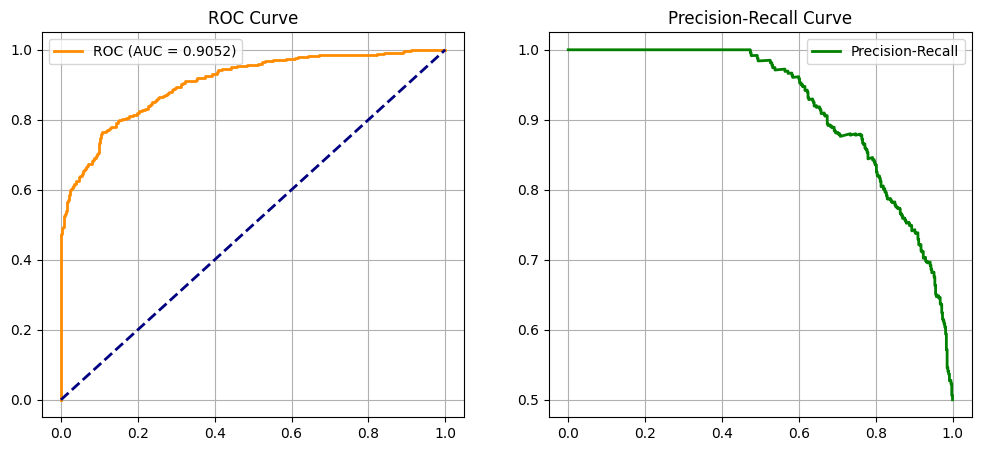

In [ ]:
# Plot curves for the Tuned model
y_prob_tuned = best_rf.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_prob_tuned)
prec, rec, _ = precision_recall_curve(y_val, y_prob_tuned)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC (AUC = {best_metrics['ROC-AUC']:.4f})")
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title("ROC Curve")
axes[0].legend()
axes[0].grid(True)
axes[1].plot(rec, prec, color='green', lw=2, label="Precision-Recall")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
axes[1].grid(True)
plt.savefig(os.path.join(PLOT_DIR, "random_forest_evaluation.png"), dpi=200)
plt.show()

### Confidence Calibration (ECE & Reliability Diagrams)

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

In [ ]:
def compute_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i+1]
        in_bin = (y_prob >= bin_lower) & (y_prob < bin_upper) if i < n_bins-1 else (y_prob >= bin_lower) & (y_prob <= bin_upper)
        bin_size = np.sum(in_bin)
        if bin_size > 0:
            acc_in_bin = np.mean(y_true[in_bin])
            conf_in_bin = np.mean(y_prob[in_bin])
            ece += (bin_size / len(y_true)) * np.abs(conf_in_bin - acc_in_bin)
    return ece


In [ ]:
# Train Platt and Isotonic calibrators
platt = CalibratedClassifierCV(estimator=best_rf, method='sigmoid', cv=5, n_jobs=-1)
platt.fit(X_train, y_train)


CalibratedClassifierCV(cv=5,
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        min_samples_split=5,
                                                        n_estimators=300,
                                                        n_jobs=-1,
                                                        random_state=42),
                       n_jobs=-1)

In [ ]:
isotonic = CalibratedClassifierCV(estimator=best_rf, method='isotonic', cv=5, n_jobs=-1)
isotonic.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        min_samples_split=5,
                                                        n_estimators=300,
                                                        n_jobs=-1,
                                                        random_state=42),
                       method='isotonic', n_jobs=-1)

In [ ]:
# Save calibrators to disk
joblib.dump(platt, os.path.join(MODEL_DIR, "platt_calibrated_model.pkl"))
joblib.dump(isotonic, os.path.join(MODEL_DIR, "isotonic_calibrated_model.pkl"))

['/content/project_outputs/models/isotonic_calibrated_model.pkl']

In [ ]:
# Probabilities
raw_probs = best_rf.predict_proba(X_val)[:, 1]
platt_probs = platt.predict_proba(X_val)[:, 1]
isotonic_probs = isotonic.predict_proba(X_val)[:, 1]
probs_dict = {
    "Uncalibrated RF": raw_probs,
    "Platt Sigmoid": platt_probs,
    "Isotonic Regression": isotonic_probs
}

In [ ]:
# Compile calibration comparison table
cal_comparison = []
for label, probs in probs_dict.items():
    ece = compute_ece(y_val, probs)
    brier = brier_score_loss(y_val, probs)
    preds = (probs >= 0.5).astype(int)
    acc = np.mean(preds == y_val)
    cal_comparison.append({
        "Calibration Method": label,
        "Accuracy": acc,
        "ECE": ece,
        "Brier Score": brier
    })
df_cal = pd.DataFrame(cal_comparison)
print("\n--- Calibration Comparison ---")
print(df_cal.to_string(index=False))


--- Calibration Comparison ---
 Calibration Method  Accuracy      ECE  Brier Score
    Uncalibrated RF     0.815 0.126422     0.144481
      Platt Sigmoid     0.820 0.070521     0.126561
Isotonic Regression     0.812 0.075887     0.128348


In [ ]:
# SAVE CALIBRATION TABLE TO CSV (Required for PDF generator!)
df_cal.to_csv(os.path.join(REPORT_DIR, "calibration_comparison.csv"), index=False)

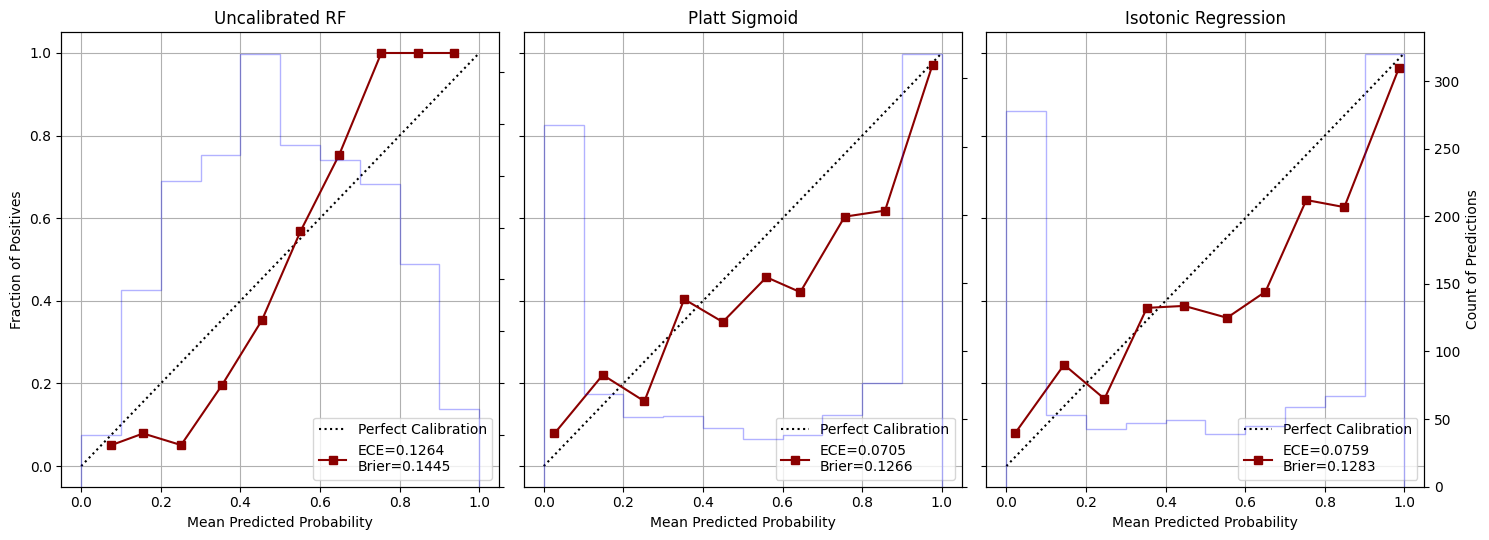

In [ ]:
# Plot Reliability curves with Prediction Count histograms (insets/twin axes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
for idx, (label, probs) in enumerate(probs_dict.items()):
    ax = axes[idx]
    prob_true, prob_pred = calibration_curve(y_val, probs, n_bins=10, strategy='uniform')
    ece = compute_ece(y_val, probs)
    brier = brier_score_loss(y_val, probs)

    ax.plot([0, 1], [0, 1], "k:", label="Perfect Calibration")
    ax.plot(prob_pred, prob_true, "s-", color="darkred", label=f"ECE={ece:.4f}\nBrier={brier:.4f}")
    ax.set_title(label)
    ax.set_xlabel("Mean Predicted Probability")
    if idx == 0:
        ax.set_ylabel("Fraction of Positives")
    ax.legend(loc="lower right")
    ax.grid(True)

    # Add histogram overlay for prediction distributions
    ax2 = ax.twinx()
    ax2.hist(probs, range=(0, 1), bins=10, histtype="step", color="blue", alpha=0.3, lw=2)
    if idx == 2:
        ax2.set_ylabel("Count of Predictions")
    else:
        ax2.set_yticklabels([])
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "reliability_comparison.png"), dpi=200)
plt.show()

#### Explainable AI (XAI) Attributions using SHAP

In [ ]:
import shap

In [ ]:
# Generate feature name list
feature_names = [f"MFCC_mean_{i}" for i in range(40)] + [f"MFCC_std_{i}" for i in range(40)]

In [ ]:
# Setup explainer
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_val)

In [ ]:
# Handle output formats
if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1] # Focus on spoof classification (class 1)
elif len(shap_values.shape) == 3:
    shap_vals_class1 = shap_values[:, :, 1]
else:
    shap_vals_class1 = shap_values

/tmp/ipykernel_6919/4067235886.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_class1, X_val, feature_names=feature_names, plot_type="bar", show=False)


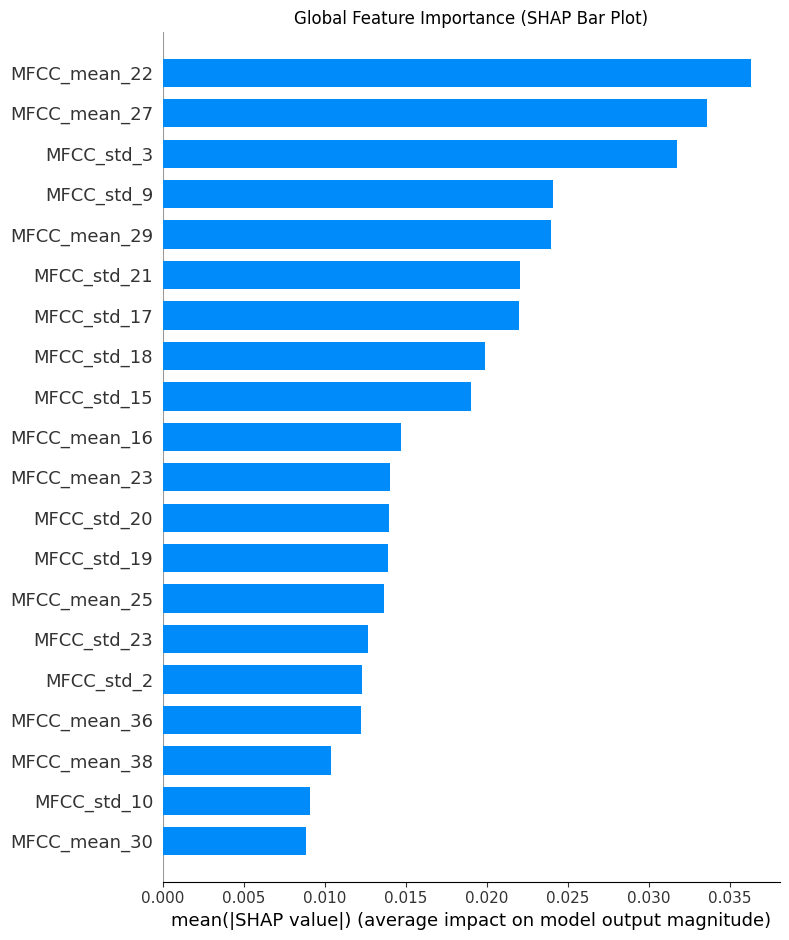

In [ ]:
# 1. Global Bar Plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_vals_class1, X_val, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP Bar Plot)")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "shap_global_bar.png"), dpi=200)
plt.show()
plt.close()

/tmp/ipykernel_6919/2431305395.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_class1, X_val, feature_names=feature_names, show=False)


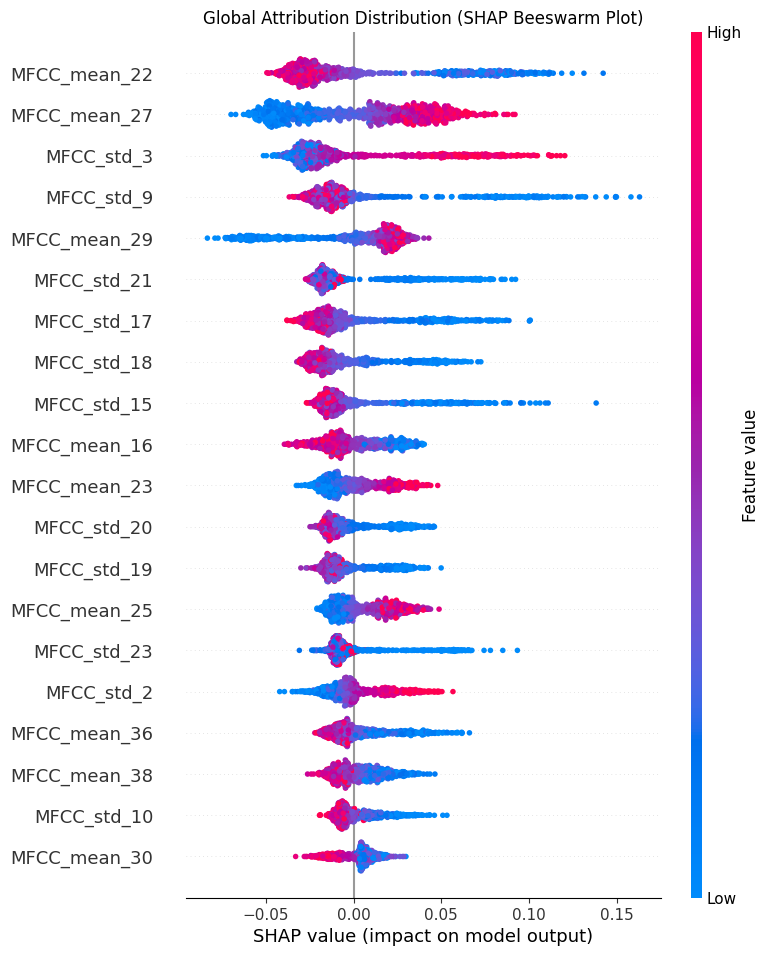

In [ ]:
# 2. Global Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_class1, X_val, feature_names=feature_names, show=False)
plt.title("Global Attribution Distribution (SHAP Beeswarm Plot)")
plt.savefig(os.path.join(PLOT_DIR, "shap_beeswarm.png"), dpi=200)
plt.show()
plt.close()

In [ ]:
# 3. Local Waterfall Explanations
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]
y_pred = best_rf.predict(X_val)
y_prob = best_rf.predict_proba(X_val)[:, 1]

In [ ]:
# Safely extract indices for correctly classified samples
bonafide_idx = np.where((y_val == 0) & (y_pred == 0) & (y_prob < 0.2))[0][0]
spoof_idx = np.where((y_val == 1) & (y_pred == 1) & (y_prob > 0.8))[0][0]

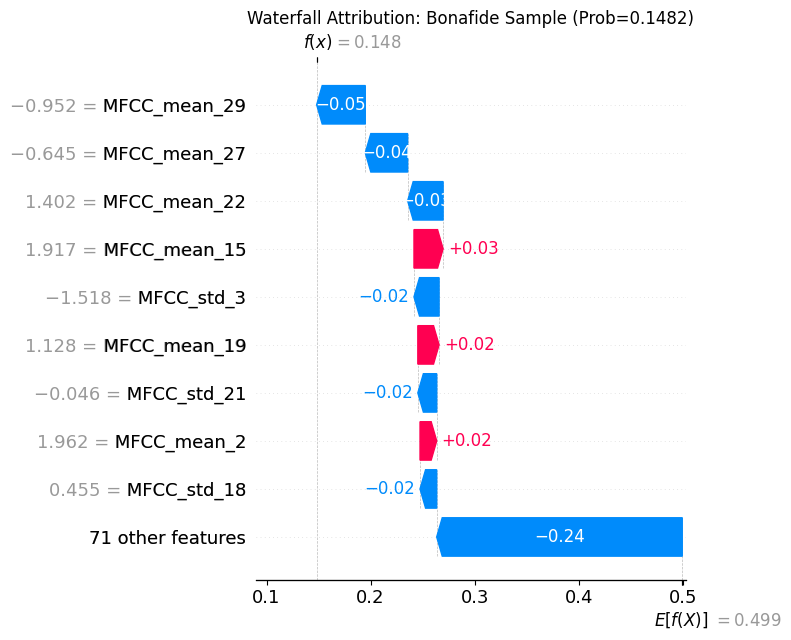

In [ ]:
# Plot Waterfall for Bonafide
exp_b = shap.Explanation(values=shap_vals_class1[bonafide_idx], base_values=expected_value, data=X_val[bonafide_idx], feature_names=feature_names)
plt.figure(figsize=(10, 5))
shap.plots.waterfall(exp_b, max_display=10, show=False)
plt.title(f"Waterfall Attribution: Bonafide Sample (Prob={y_prob[bonafide_idx]:.4f})")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "shap_local_waterfall_bonafide.png"), dpi=200)
plt.show()
plt.close()

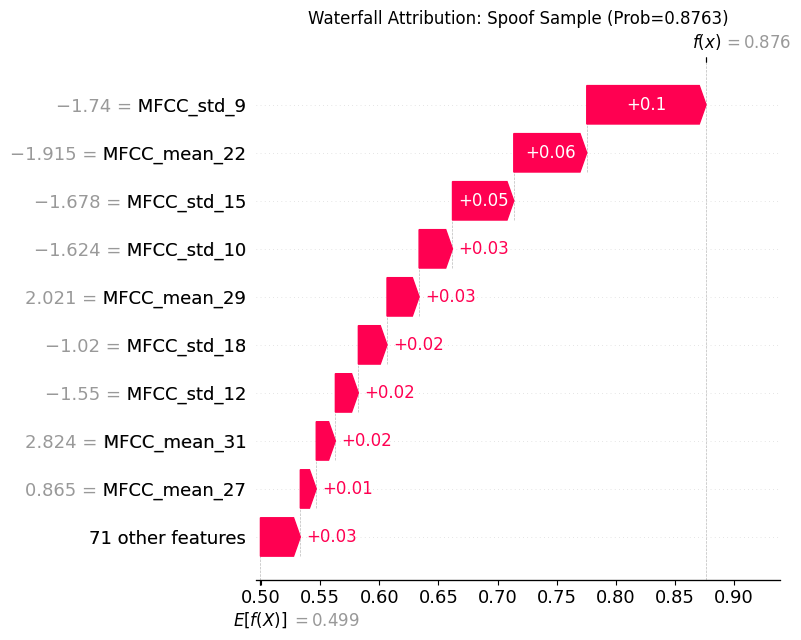

In [ ]:
# Plot Waterfall for Spoof
exp_s = shap.Explanation(values=shap_vals_class1[spoof_idx], base_values=expected_value, data=X_val[spoof_idx], feature_names=feature_names)
plt.figure(figsize=(10, 5))
shap.plots.waterfall(exp_s, max_display=10, show=False)
plt.title(f"Waterfall Attribution: Spoof Sample (Prob={y_prob[spoof_idx]:.4f})")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "shap_local_waterfall_spoof.png"), dpi=200)
plt.show()
plt.close()

#### Complete PDF Summary Report Generation (ReportLab)

In [ ]:
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
import pandas as pd


In [ ]:

# Load CSV metrics saved in preceding cells
baseline_csv = os.path.join(REPORT_DIR, "baseline_model_evaluation_metrics.csv")
best_csv = os.path.join(REPORT_DIR, "best_model_evaluation_metrics.csv")
cal_csv = os.path.join(REPORT_DIR, "calibration_comparison.csv")

In [ ]:
eval_metrics = pd.read_csv(best_csv).iloc[0].to_dict()
cal_df = pd.read_csv(cal_csv)
pdf_path = os.path.join(REPORT_DIR, "deepfake_detection_report.pdf")
doc = SimpleDocTemplate(pdf_path, pagesize=letter, rightMargin=40, leftMargin=40, topMargin=40, bottomMargin=40)
story = []
styles = getSampleStyleSheet()

In [ ]:
primary_color = colors.HexColor("#1A365D")
secondary_color = colors.HexColor("#2B6CB0")
bg_light = colors.HexColor("#F7FAFC")
border_color = colors.HexColor("#E2E8F0")

In [ ]:
title_style = ParagraphStyle('DocTitle', parent=styles['Normal'], fontName='Helvetica-Bold', fontSize=22, textColor=primary_color, leading=26, spaceAfter=4)
subtitle_style = ParagraphStyle('DocSubtitle', parent=styles['Normal'], fontName='Helvetica', fontSize=11, textColor=colors.HexColor("#4A5568"), leading=14, spaceAfter=15)
h1_style = ParagraphStyle('SectionHeading', parent=styles['Normal'], fontName='Helvetica-Bold', fontSize=14, textColor=primary_color, leading=18, spaceBefore=12, spaceAfter=8, keepWithNext=True)
h2_style = ParagraphStyle('SubsectionHeading', parent=styles['Normal'], fontName='Helvetica-Bold', fontSize=11, textColor=secondary_color, leading=14, spaceBefore=8, spaceAfter=4, keepWithNext=True)
body_style = ParagraphStyle('BodyTextCustom', parent=styles['Normal'], fontName='Helvetica', fontSize=9, textColor=colors.HexColor("#2D3748"), leading=13, spaceAfter=6)

In [ ]:
story.append(Paragraph("Explainable Deepfake Audio Detection Report", title_style))
story.append(Paragraph("System Evaluation, Confidence Calibration, and Feature Attribution Summary", subtitle_style))


In [ ]:

# Section 1: Methodology
story.append(Paragraph("1. System Architecture & Methodology", h1_style))
story.append(Paragraph("This report documents the validation results of the machine learning pipeline constructed to identify synthetic speech deepfakes using the ASVspoof 2019 dataset.", body_style))

In [ ]:
# Section 2: Performance
story.append(Paragraph("2. ML Model Classification Performance", h1_style))
perf_data = [
    [Paragraph("<b>Metric</b>", body_style), Paragraph("<b>Value</b>", body_style)],
    [Paragraph("Accuracy", body_style), Paragraph(f"{eval_metrics['Accuracy']:.4%}", body_style)],
    [Paragraph("Precision", body_style), Paragraph(f"{eval_metrics['Precision']:.4%}", body_style)],
    [Paragraph("Recall (TPR)", body_style), Paragraph(f"{eval_metrics['Recall']:.4%}", body_style)],
    [Paragraph("F1-Score", body_style), Paragraph(f"{eval_metrics['F1-Score']:.4%}", body_style)],
    [Paragraph("ROC-AUC", body_style), Paragraph(f"{eval_metrics['ROC-AUC']:.4f}", body_style)],
    [Paragraph("Confusion Matrix", body_style), Paragraph(f"TP={int(eval_metrics['TP'])}, TN={int(eval_metrics['TN'])}, FP={int(eval_metrics['FP'])}, FN={int(eval_metrics['FN'])}", body_style)]
]
t_perf = Table(perf_data, colWidths=[150, 300])
t_perf.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (1,0), secondary_color),
    ('TEXTCOLOR', (0,0), (1,0), colors.white),
    ('GRID', (0,0), (-1,-1), 1, border_color),
    ('BACKGROUND', (0,1), (-1,-1), bg_light),
    ('BOTTOMPADDING', (0,0), (-1,-1), 4),
]))
story.append(t_perf)
roc_img = os.path.join(PLOT_DIR, "random_forest_evaluation.png")
if os.path.exists(roc_img):
    story.append(Spacer(1, 10))
    story.append(Paragraph("<b>Figure 1: Classification Curves</b>", h2_style))
    story.append(Image(roc_img, width=380, height=160))

In [ ]:
# Section 3: Calibration
story.append(Spacer(1, 10))
story.append(Paragraph("3. Confidence Calibration Results", h1_style))
cal_data = [[Paragraph(f"<b>{col}</b>", body_style) for col in cal_df.columns]]
for _, row in cal_df.iterrows():
    cal_data.append([
        Paragraph(str(row["Calibration Method"]), body_style),
        Paragraph(f"{row['Accuracy']:.4%}", body_style),
        Paragraph(f"{row['ECE']:.4f}", body_style),
        Paragraph(f"{row['Brier Score']:.4f}", body_style)
    ])
t_cal = Table(cal_data, colWidths=[160, 95, 95, 95])
t_cal.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), secondary_color),
    ('TEXTCOLOR', (0,0), (-1,0), colors.white),
    ('GRID', (0,0), (-1,-1), 1, border_color),
    ('BACKGROUND', (0,1), (-1,-1), bg_light),
    ('BOTTOMPADDING', (0,0), (-1,-1), 4),
]))
story.append(t_cal)
cal_img = os.path.join(PLOT_DIR, "reliability_comparison.png")
if os.path.exists(cal_img):
    story.append(Spacer(1, 10))
    story.append(Paragraph("<b>Figure 2: Reliability Diagrams</b>", h2_style))
    story.append(Image(cal_img, width=400, height=145))

In [ ]:
# Section 4: Explainability
story.append(Spacer(1, 10))
story.append(Paragraph("4. Explainable AI Attributions", h1_style))
beeswarm_img = os.path.join(PLOT_DIR, "shap_beeswarm.png")
if os.path.exists(beeswarm_img):
    story.append(Paragraph("<b>Figure 3: Global Feature Attributions (SHAP Beeswarm)</b>", h2_style))
    story.append(Image(beeswarm_img, width=380, height=300))

In [ ]:
# Build Document
doc.build(story)
print(f"Professional PDF report successfully generated at: {pdf_path}")

Professional PDF report successfully generated at: /content/project_outputs/reports/deepfake_detection_report.pdf


#### Google Drive Backup Execution

In [ ]:
# Destination folder inside your mounted Google Drive
drive_backup_dir = "/content/drive/MyDrive/asvspoof2019/project_outputs"

In [ ]:
# Remove any old version to prevent folder nesting
if os.path.exists(drive_backup_dir):
    shutil.rmtree(drive_backup_dir)

In [ ]:
# Create parent directories if needed
os.makedirs(os.path.dirname(drive_backup_dir), exist_ok=True)

In [ ]:
# Copy the entire local output folder to Google Drive
shutil.copytree(OUTPUT_DIR, drive_backup_dir)
print(f"All project outputs (models, feature matrices, curves, and the final PDF) backed up to Google Drive at: {drive_backup_dir}")

All project outputs (models, feature matrices, curves, and the final PDF) backed up to Google Drive at: /content/drive/MyDrive/asvspoof2019/project_outputs
